# Эксперимент 14: HuBERT + LSTM + ResNet-50 + Transformer

**Статья:** Hybrid-Module Transformer: enhancing speech emotion recognition with HuBERT, LSTM, and ResNet-50 (Гибридный модульный Transformer: улучшение распознавания речевых эмоций с HuBERT, LSTM и ResNet-50) 2024

**Ссылка:** [https://peerj.com/articles/cs-3292/](https://peerj.com/articles/cs-3292/)

**Краткое описание модели:** Гибридный мультимодульный стек: HuBERT/LSTM ветка + ResNet-ветка + Transformer fusion.

**Содержание статьи:** Статья демонстрирует, что комбинация self-supervised признаков и глубоких сверточных блоков улучшает качество на речевых задачах. Transformer-модуль служит механизмом согласования контекстов разных веток. Эксперимент проверяет полный гибрид в условиях вашего датасета.

In [1]:
import sys
from pathlib import Path
import numpy as np
import time
import torch
from torch.utils.data import DataLoader
from torch import nn
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import f1_score, accuracy_score, roc_auc_score, precision_score, recall_score, classification_report
import matplotlib.pyplot as plt
import pandas as pd

exp_dir = Path().resolve()
sys.path.insert(0, str(exp_dir.parent))
sys.path.insert(0, str(exp_dir))

from shared import config, data_utils, train_utils
from shared.results_utils import save_result_csv
from model import get_model

## 1. Разбиение и датасет (waveform + mel)

In [ ]:
paths_train, paths_val, paths_test, y_train, y_val, y_test, letters_train, letters_val, letters_test = data_utils.get_splits()
print(f"Train: {len(paths_train)}, Val: {len(paths_val)}, Test: {len(paths_test)}")
n_letters = letters_train.shape[1]

SR = config.TARGET_SR
MAX_SEC = config.MAX_DURATION_SEC
MAX_LEN = int(SR * MAX_SEC)
N_MELS = config.N_MELS
N_FRAMES = 320

def load_waveform(path):
    y, _ = data_utils.load_audio(path, sr=SR, max_sec=MAX_SEC)
    if len(y) < MAX_LEN:
        y = np.pad(y, (0, MAX_LEN - len(y)), mode="constant", constant_values=0)
    else:
        y = y[:MAX_LEN]
    return y.astype(np.float32)

def load_mel(path):
    mel = data_utils.extract_mel_spectrogram(path, max_frames=N_FRAMES)
    return mel[np.newaxis, ...]

class WaveformMelDataset(torch.utils.data.Dataset):
    def __init__(self, paths, labels, letters):
        self.paths = paths
        self.labels = labels
        self.letters = letters
    def __len__(self):
        return len(self.paths)
    def __getitem__(self, i):
        wav = load_waveform(self.paths[i])
        mel = load_mel(self.paths[i])
        let = torch.from_numpy(self.letters[i].astype(np.float32))
        return torch.from_numpy(wav), torch.from_numpy(mel).float(), let, self.labels[i]

train_ds = WaveformMelDataset(paths_train, y_train, letters_train)
val_ds   = WaveformMelDataset(paths_val, y_val, letters_val)
test_ds  = WaveformMelDataset(paths_test, y_test, letters_test)
print(f"Waveform: {MAX_LEN} сэмплов, Mel: (1, {N_MELS}, {N_FRAMES})")

Train: 1942, Val: 417, Test: 417
Waveform: 160000 сэмплов, Mel: (1, 80, 320)


In [3]:
mel_mean = None
mel_std = None
def normalize_mel(mel_batch):
    global mel_mean, mel_std
    if mel_mean is None:
        return mel_batch
    return (mel_batch - mel_mean) / mel_std

all_mels = np.stack([load_mel(p) for p in paths_train[:500]])
mel_mean = all_mels.mean(axis=(0, 2, 3), keepdims=True)
mel_std = all_mels.std(axis=(0, 2, 3), keepdims=True)
mel_std = np.where(mel_std < 1e-6, 1.0, mel_std)
print("Нормализация mel по train (500 сэмплов): ok")

Нормализация mel по train (500 сэмплов): ok


## 2. DataLoader и модель

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

BATCH_SIZE = 8
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=(device.type=="cuda"))
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False)

Device: cuda


In [5]:
model = get_model(num_classes=2, n_letters=n_letters, dropout=0.3, freeze_hubert=True, lstm_hidden=128).to(device)
n_params = sum(p.numel() for p in model.parameters())
n_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Параметров: {n_params}, обучаемых: {n_trainable}")

I0000 00:00:1774514623.697004 1287197 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Параметров: 122548946, обучаемых: 28177234


## 3. Обучение

In [6]:
weights = compute_class_weight("balanced", classes=np.unique(y_train), y=y_train)
class_weights = torch.tensor(weights, dtype=torch.float32, device=device)
criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=5e-4)
scheduler = train_utils.get_lr_scheduler(optimizer, patience=config.LR_SCHEDULER_PATIENCE, factor=config.LR_SCHEDULER_FACTOR)
early_stopping = train_utils.EarlyStopping(patience=config.EARLY_STOPPING_PATIENCE)
best_ckpt_path = exp_dir / "best_ckpt.pt"
best_f1 = -1.0

In [7]:
def eval_loader(loader):
    model.eval()
    all_pred, all_true = [], []
    with torch.no_grad():
        for wav, mel, letters, y in loader:
            wav = wav.to(device)
            mel = mel.to(device)
            if mel_mean is not None:
                mel = (mel - torch.from_numpy(mel_mean).to(device)) / torch.from_numpy(mel_std).to(device)
            letters = letters.to(device)
            y = y.to(device)
            logits = model(wav, mel, letters=letters)
            pred = logits.argmax(dim=1)
            all_pred.append(pred.cpu().numpy())
            all_true.append(y.cpu().numpy())
    return np.concatenate(all_pred), np.concatenate(all_true)

N_EPOCHS = 50
train_losses, val_f1s = [], []
t0 = time.perf_counter()
for epoch in range(N_EPOCHS):
    model.train()
    epoch_losses = []
    for wav, mel, letters, y in train_loader:
        wav, letters, y = wav.to(device), letters.to(device), y.to(device)
        mel = mel.to(device)
        if mel_mean is not None:
            mel = (mel - torch.from_numpy(mel_mean).to(device)) / torch.from_numpy(mel_std).to(device)
        optimizer.zero_grad()
        loss = criterion(model(wav, mel, letters=letters), y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=config.DEFAULT_GRAD_CLIP)
        optimizer.step()
        epoch_losses.append(loss.item())
    train_losses.append(np.mean(epoch_losses))
    vp, vt = eval_loader(val_loader)
    val_f1 = f1_score(vt, vp, average="macro")
    val_f1s.append(val_f1)
    if val_f1 > best_f1:
        best_f1 = val_f1
        train_utils.save_best_checkpoint(model, best_ckpt_path)
    scheduler.step(val_f1)
    print(f"Epoch {epoch+1}/{N_EPOCHS}  train_loss={train_losses[-1]:.4f}  val_f1_macro={val_f1:.4f}")
    if early_stopping.step(val_f1):
        print(f"Early stopping на эпохе {epoch+1}")
        break
train_time_sec = time.perf_counter() - t0
train_utils.load_best_checkpoint(model, best_ckpt_path, device)
print(f"Обучение заняло {train_time_sec:.1f} с. Загружен лучший чекпоинт (val_f1_macro={best_f1:.4f}).")

Epoch 1/50  train_loss=0.7092  val_f1_macro=0.6847
Epoch 2/50  train_loss=0.6167  val_f1_macro=0.7402
Epoch 3/50  train_loss=0.5549  val_f1_macro=0.7616
Epoch 4/50  train_loss=0.5375  val_f1_macro=0.7413
Epoch 5/50  train_loss=0.4857  val_f1_macro=0.7816
Epoch 6/50  train_loss=0.4499  val_f1_macro=0.7667
Epoch 7/50  train_loss=0.3971  val_f1_macro=0.7719
Epoch 8/50  train_loss=0.3410  val_f1_macro=0.7539
Epoch 9/50  train_loss=0.3174  val_f1_macro=0.7538
Epoch 10/50  train_loss=0.2406  val_f1_macro=0.7589
Epoch 11/50  train_loss=0.2156  val_f1_macro=0.7775
Epoch 12/50  train_loss=0.1423  val_f1_macro=0.7862
Epoch 13/50  train_loss=0.0838  val_f1_macro=0.7760
Epoch 14/50  train_loss=0.0723  val_f1_macro=0.7948
Epoch 15/50  train_loss=0.0549  val_f1_macro=0.7692
Epoch 16/50  train_loss=0.0413  val_f1_macro=0.7802
Epoch 17/50  train_loss=0.0573  val_f1_macro=0.7707
Epoch 18/50  train_loss=0.0537  val_f1_macro=0.7778
Epoch 19/50  train_loss=0.0486  val_f1_macro=0.7482
Epoch 20/50  train_lo

## 4. Графики и оценка на тесте

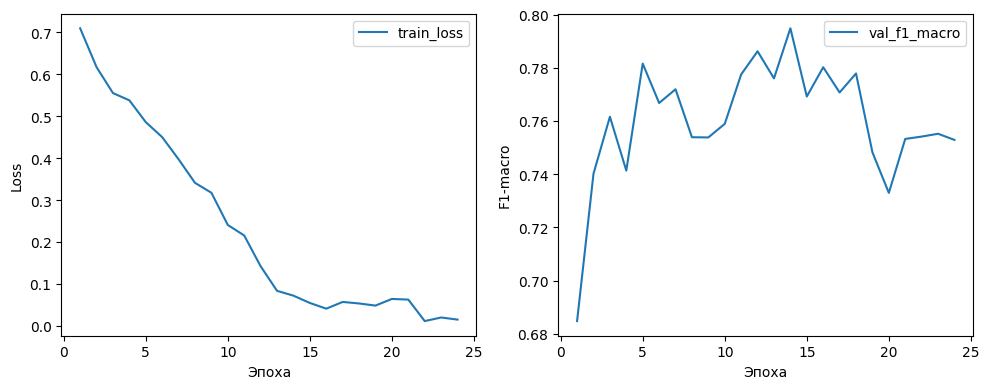

In [8]:
n_epochs_done = len(train_losses)
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(range(1, n_epochs_done + 1), train_losses, label="train_loss")
plt.xlabel("Эпоха")
plt.ylabel("Loss")
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(range(1, n_epochs_done + 1), val_f1s, label="val_f1_macro")
plt.xlabel("Эпоха")
plt.ylabel("F1-macro")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
model.eval()
all_logits = []
with torch.no_grad():
    for wav, mel, letters, _ in test_loader:
        wav, mel, letters = wav.to(device), mel.to(device), letters.to(device)
        if mel_mean is not None:
            mel = (mel - torch.from_numpy(mel_mean).to(device)) / torch.from_numpy(mel_std).to(device)
        all_logits.append(model(wav, mel, letters=letters).cpu().numpy())
logits = np.concatenate(all_logits)
y_pred = np.argmax(logits, axis=1)
y_proba = torch.softmax(torch.from_numpy(logits), dim=1).numpy()[:, config.CLASS_BAD]

accuracy = accuracy_score(y_test, y_pred)
f1_macro = f1_score(y_test, y_pred, average="macro")
f1_bad   = f1_score(y_test, y_pred, pos_label=config.CLASS_BAD)
roc_auc  = roc_auc_score(y_test, y_proba)
precision_bad = precision_score(y_test, y_pred, pos_label=config.CLASS_BAD, zero_division=0)
recall_bad    = recall_score(y_test, y_pred, pos_label=config.CLASS_BAD, zero_division=0)

print(classification_report(y_test, y_pred, target_names=config.CLASS_NAMES))
print(f"Accuracy: {accuracy:.4f}")
print(f"F1 macro: {f1_macro:.4f}")
print(f"F1 (bad): {f1_bad:.4f}")
print(f"ROC-AUC:  {roc_auc:.4f}")

save_result_csv(
    exp_dir=exp_dir,
    experiment_id="exp_14_hubert_resnet_transformer",
    experiment_name="HuBERT+ResNet50+Transformer",
    model="HybridModuleTransformer",
    accuracy=accuracy,
    f1_macro=f1_macro,
    f1_bad=f1_bad,
    roc_auc=roc_auc,
    precision_bad=precision_bad,
    recall_bad=recall_bad,
    notes="Full hybrid: HuBERT-LSTM 768 + ResNet50 2048, 4-layer Transformer, 10s",
    train_time_sec=train_time_sec,
)

              precision    recall  f1-score   support

        good       0.78      0.89      0.83       282
         bad       0.68      0.48      0.56       135

    accuracy                           0.76       417
   macro avg       0.73      0.69      0.70       417
weighted avg       0.75      0.76      0.75       417

Accuracy: 0.7578
F1 macro: 0.6976
F1 (bad): 0.5628
ROC-AUC:  0.8197


PosixPath('/mnt/d/Projects/а\x92аЈа\xad/cursor/VKR/experiments/exp_14_hubert_resnet_transformer/result.csv')